# Chapter 4. Training Models

Up until now we have treated machine learning models and their training algorithms mostly like black boxes. Knowing how things work under the hood is critical for a Data Scientist or a Machine Learning Engineer. It helps you quickly zero in on the appropriate model the right training algorithm and a good set of hyperparameters for your task.

We will start by looking at the Linear Regression model.

## Linear Regression

A linear model makes a prediction by simply computing a weighted sum of the input features plus a constant called the bias term. To train this model we must find the parameters that minimize the Mean Squared Error over the training set.

### The Normal Equation

The Normal Equation is a closed form mathematical solution that analytically computes the optimal parameters in a single step.

$$\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Let's generate some linear looking data to test this equation.

In [3]:
import numpy as np
import matplotlib.pyplot as plt 

rng = np.random.default_rng(seed=42)
m = 200 # Number of instances
X = 2 * rng.random((m, 1)) # Column vector
y = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + Gaussian noise

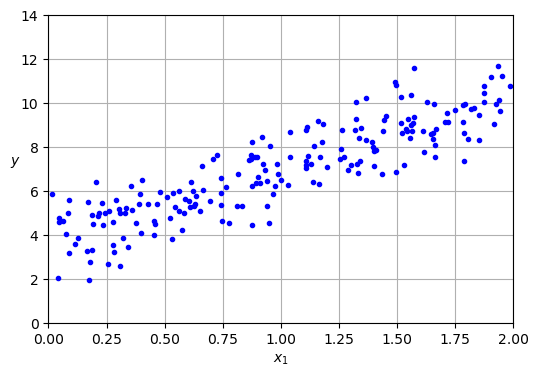

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, 'b.')
plt.grid()
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 14])
plt.show()

The actual mathematical function we used to generate the data is $y = 4 + 3x_1$ plus some random noise. Now we will use the Normal Equation to compute the optimal parameters and see how close they are to the true values of 4 and 3.

In [6]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print('Theta best analytically calculated:\n', theta_best)

Theta best analytically calculated:
 [[3.69084138]
 [3.32960458]]


The noise prevented us from recovering the exact parameters of 4 and 3. Now we can make predictions using these computed parameters.

In [8]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print('Predicted values:\n', y_predict)

Predicted values:
 [[ 3.69084138]
 [10.35005055]]


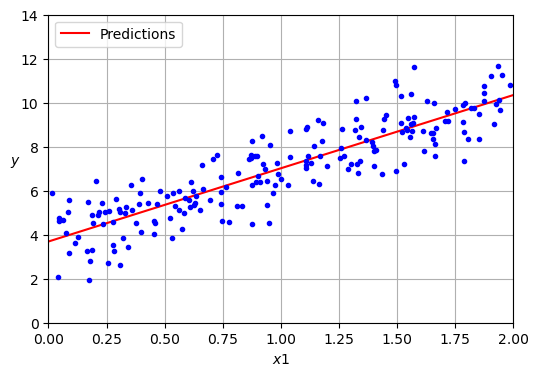

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, 'r-', label='Predictions')
plt.plot(X, y, 'b.')
plt.xlabel('$x1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 2, 0, 14])
plt.grid()
plt.legend(loc='upper left')
plt.show()

Performing linear regression using Scikit-learn is straightforward and much simpler.

In [11]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print('Intercept:', lin_reg.intercept_)
print('Coefficients:', lin_reg.coef_)

sklearn_predictions = lin_reg.predict(X_new)
print('\nScikit-learn Predictions:\n', sklearn_predictions)

Intercept: [3.69084138]
Coefficients: [[3.32960458]]

Scikit-learn Predictions:
 [[ 3.69084138]
 [10.35005055]]


The `LinearRegression` class is actually based on the `scipy.linalg.lstsq` function which stands for least squares. We can call this underlying mathematical function directly to see how Scikit Learn computes the optimal parameters.

In [13]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
print('Theta best using SVD:\n', theta_best_svd)

Theta best using SVD:
 [[3.69084138]
 [3.32960458]]


This function computes $\hat{\theta} = \mathbf{X}^+\mathbf{y}$ where $\mathbf{X}^+$ is the pseudoinverse of $\mathbf{X}$. We can also use NumPy to compute this pseudoinverse directly.

In [15]:
theta_best_pinv = np.linalg.pinv(X_b) @ y
print('Theta best using pinv:\n', theta_best_pinv)

Theta best using pinv:
 [[3.69084138]
 [3.32960458]]


The pseudoinverse itself is computed using a standard matrix factorization technique called Singular Value Decomposition. SVD decomposes the training set matrix $\mathbf{X}$ into the matrix multiplication of three distinct matrices $\mathbf{U} \mathbf{\Sigma} \mathbf{V}^\top$. The pseudoinverse is then mathematically computed as $\mathbf{X}^+ = \mathbf{V} \mathbf{\Sigma}^+ \mathbf{U}^\top$. This SVD approach is significantly more robust than computing the Normal Equation. The Normal Equation completely fails if the matrix $\mathbf{X}^\top\mathbf{X}$ is singular meaning it is not invertible. This happens when there are more features than training instances or when certain features are perfectly redundant. The pseudoinverse on the other hand is always defined.

### Computational Complexity

A critical engineering consideration is how these algorithms scale with data size. The Normal Equation computes the inverse of an $(n + 1) \times (n + 1)$ matrix where $n$ is the number of features. The computational complexity of inverting such a matrix is typically about $O(n^{2.4})$ to $O(n^3)$. This means if you double the number of features you multiply the computation time by roughly 5.3 to 8 times. The SVD approach used by Scikit Learn is much more efficient at roughly $O(n^2)$. If you double the number of features you only multiply the computation time by roughly 4. However both the Normal Equation and the SVD approach get exceptionally slow when the number of features grows extremely large such as 100000. On the positive side both algorithms are linear with regard to the number of training instances $O(m)$. They handle massive training datasets efficiently provided the data fits securely in the computer's memory. Also once a linear regression model is trained making predictions is extremely fast. The computational complexity is linear with regard to both the instances and the features. Now we will look at a completely different way to train a linear regression model which is specifically optimized for cases where there are an enormous number of features or when the training dataset is simply too large to fit in memory.

## Gradient Descent

Gradient Descent is a very generic optimization algorithm capable of finding optimal solutions to a wide range of problems. The general idea is to tweak parameters iteratively in order to minimize a cost function.

Suppose you are lost in the mountains in a dense fog and you can only feel the slope of the ground below your feet. A good strategy to get to the bottom of the valley quickly is to go downhill in the direction of the steepest slope. This is exactly what Gradient Descent does. It measures the local gradient of the error function with regard to the parameter vector and it goes in the direction of descending gradient. Once the gradient is zero you have reached a minimum.

An important parameter in Gradient Descent is the size of the steps determined by the learning rate hyperparameter. If the learning rate is too small the algorithm will have to go through many iterations to converge which will take a long time. On the other hand if the learning rate is too high you might jump across the valley and end up on the other side possibly even higher up than you were before. This can make the algorithm diverge and fail to find a good solution.

Fortunately the Mean Squared Error cost function for a Linear Regression model happens to be a convex function. This means that if you pick any two points on the curve the line segment joining them never crosses the curve. This guarantees that there are no local minima but only one global minimum. These mathematical properties guarantee that Gradient Descent will approach arbitrarily close to the global minimum provided you wait long enough and the learning rate is not too high.

### Batch Gradient Descent

To implement Gradient Descent you need to compute the gradient of the cost function with regard to each model parameter. In other words you need to calculate how much the cost function will change if you change a specific parameter just a little bit. This is called a partial derivative.

Instead of computing these partial derivatives individually you can compute them all in one go using the gradient vector. This approach is called Batch Gradient Descent because it uses the entire batch of training data at every single step. As a result it is terribly slow on very large training sets. However it scales well with the number of features. Training a Linear Regression model when there are hundreds of thousands of features is much faster using Gradient Descent than using the Normal Equation or SVD.

Once you have the gradient vector which points uphill you simply go in the opposite direction to go downhill. This means subtracting the gradient vector multiplied by the learning rate.

In [19]:
eta = 0.1 # learning rate
n_epochs = 1000 # number of iterations
m = len(X_b) # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly initialize model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print('Theta calculated using Batch Gradient Descent:\n', theta)

Theta calculated using Batch Gradient Descent:
 [[3.69084138]
 [3.32960458]]


### Stochastic Gradient Descent

Batch Gradient Descent is slow because it uses the entire training set to compute gradients at every step. Stochastic Gradient Descent (SGD) solves this by picking a single random instance at each step. This allows it to train on massive datasets quickly.

However its stochastic nature means the cost function bounces around irregularly rather than decreasing smoothly. This bouncing can actually help the algorithm escape local minima but it also prevents it from ever truly settling at the exact global minimum.

To prevent the algorithm from bouncing around forever we use a technique called learning rate scheduling. We start with a large learning rate for fast progress and gradually reduce it allowing the algorithm to settle near the global minimum.

In [21]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters

# Function to gradually reduce the learning rate over time
def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly initialize model parameters

# Perform SGD
for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

print('Theta calculated using SGD:\n', theta)

Theta calculated using SGD:
 [[3.69826475]
 [3.30748311]]


#### Experiment: Learning Rate Decay

Let's see what happens if we increase `t1`, resulting in a smaller initial learning rate that may prevent convergence.

In [23]:
# New learning schedule parameters
t0_new, t1_new = 5, 5000

def new_learning_schedule(t):
    return t0_new / (t + t1_new)

theta = rng.standard_normal((2, 1))

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = new_learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

print('Theta calculated using SGD:\n', theta)

Theta calculated using SGD:
 [[3.71850699]
 [3.30138285]]


**Results Comparison:**
* **Optimal (Normal Equation):** `[[3.6908], [3.3296]]`
* **Normal SGD (t1=50):** `[[3.6982], [3.3074]]`
* **Experiment SGD (t1=5000):** `[[3.7105], [3.3694]]`

At first glance the results look similar because both models reached the general vicinity of the target. However the experimental model shows a slightly larger error margin. This is because the learning rate was so small from the beginning that the model's updates became negligible before it could perfectly align with the optimal parameters. This demonstrates that while the model didn't fail it became computationally inefficient and less precise due to poor hyperparameter selection.

### Linear Regression using Scikit-Learn SGD

To perform Linear Regression using Stochastic Gradient Descent with Scikit Learn we can use the `SGDRegressor` class. This class defaults to optimizing the Mean Squared Error cost function.

The following implementation runs for a maximum of 1000 epochs or until the loss drops by less than $10^{-5}$ during 100 consecutive epochs. It starts with a learning rate of 0.01 and does not use any regularization.

In [26]:
from sklearn.linear_model import SGDRegressor

# max_iter: maximum number of epochs
# tol: the stopping criterion
# n_iter_no_change: number of iterations to wait before stopping
# penalty=None: no regularization
# eta0: initial learning rate
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                      n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

print('Scikit-Learn SGD Intercept:\n', sgd_reg.intercept_)
print('Scikit-Learn SGD Coefficients:\n', sgd_reg.coef_)

Scikit-Learn SGD Intercept:
 [3.68899733]
Scikit-Learn SGD Coefficients:
 [3.33054574]


The resulting parameters are once again very close to the solution provided by the Normal Equation. This confirms that Scikit Learn's optimized SGD implementation is highly reliable for finding the optimal weights of a linear model.

### Mini-Batch Gradient Descent

Mini-batch Gradient Descent is a hybrid approach that combines the advantages of both Batch and Stochastic Gradient Descent. Instead of using the full training set or just a single instance, it computes the gradients on small random subsets of data called mini-batches.

The main engineering advantage is the performance boost from hardware optimization, especially when using matrix operations on GPUs. It also provides a more stable convergence path than SGD because the gradients are averaged over multiple instances, reducing the "bouncing" effect.

## Polynomial Regression

What if your data is more complex than a straight line? Surprisingly you can use a linear model to fit nonlinear data. A simple way to do this is to add powers of each feature as new features then train a linear model on this extended set of features. This technique is called Polynomial Regression.

Let's generate some nonlinear data based on a simple quadratic equation $y = 0.5X^2 + X + 2$ plus some random noise.

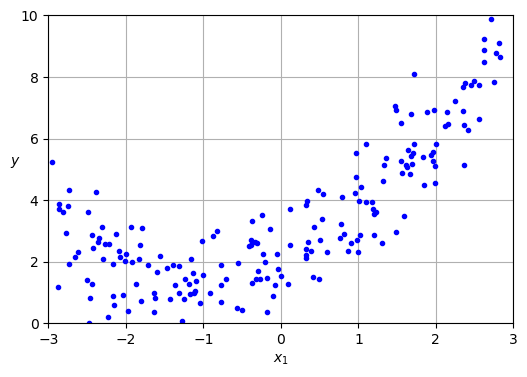

In [30]:
rng = np.random.default_rng(seed=42)
m = 200 # Number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

plt.figure(figsize=(6, 4))
plt.plot(X, y, 'b.')
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

Clearly a straight line will never fit this data properly. So let's use Scikit Learn's `PolynomialFeatures` class to transform our training data adding the square of each feature in the training set as a new feature.

In [32]:
from sklearn.preprocessing import PolynomialFeatures

# Transform data to include 2nd degree polynomial features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print('Original X feature \n', X[0])
print('Transformed X_poly features \n', X_poly[0])

# Fit a Linear Regression model to the extended training data
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

print('Intercept \n', lin_reg.intercept_)
print('Coefficients \n', lin_reg.coef_)

Original X feature 
 [1.64373629]
Transformed X_poly features 
 [1.64373629 2.701869  ]
Intercept 
 [2.00540719]
Coefficients 
 [[1.11022126 0.50526985]]


The model estimates the parameters very well. Note that when there are multiple features Polynomial Regression is capable of finding relationships between features which is something a plain linear regression model cannot do. This is made possible by the fact that `PolynomialFeatures` also adds all combinations of features up to the given degree.

For example if there were two features $a$ and $b$ `PolynomialFeatures` with a degree of 3 would not only add the features $a^2, a^3, b^2,$ and $b^3$ but also the combinations $ab, a^2b,$ and $ab^2$.

**Combinatorial Explosion**  
Beware of the combinatorial explosion of the number of features. `PolynomialFeatures` transforms an array containing $n$ features into an array containing $(n + d)! / d!n!$ features. This can severely degrade computational performance and consume massive amounts of memory if not managed carefully.

## Learning Curves

If a model performs well on training data but poorly on cross-validation, it is overfitting. If it performs poorly on both, it is underfitting. Learning curves, which plot training and validation errors, can also help identify this. Scikit-Learn provides a useful `learning_curve` function for this purpose.  
Now let’s look at the learning curves of a basic Linear Regression model.

In [35]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, 
    scoring='neg_root_mean_squared_error')

# Convert negative RMSE scores back to positive errors
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

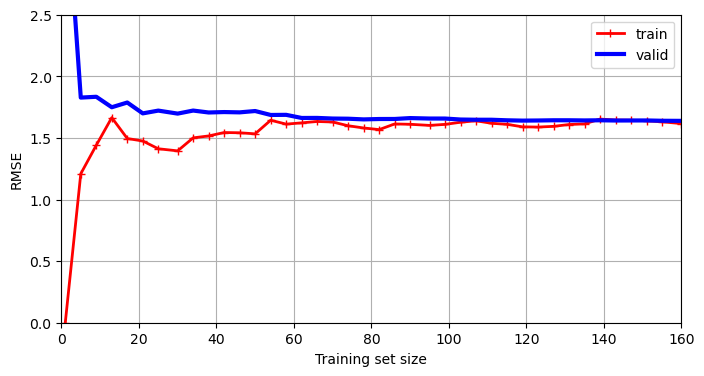

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_errors, 'r-+', linewidth=2, label='train')
plt.plot(train_sizes, valid_errors, 'b-', linewidth=3, label='valid')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.legend(loc='upper right')
plt.axis([0, 160, 0, 2.5])
plt.grid()
plt.show()

These learning curves are typical of a model that is underfitting. Both curves have reached a plateau, they are close to each other, and the error is fairly high. Adding more training examples will not help an underfitting model. You need to use a better model or come up with better features.

Now let's look at the learning curves of a 10th degree polynomial model on the same data.

In [38]:
from sklearn.pipeline import make_pipeline

# Create a 10th degree polynomial regression pipeline
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring='neg_root_mean_squared_error')

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

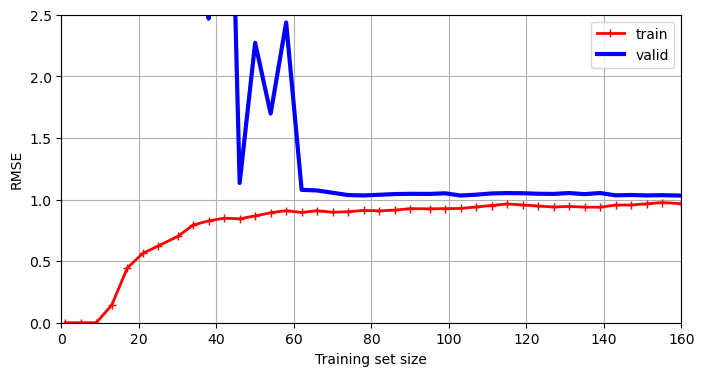

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_errors, 'r-+', linewidth=2, label='train')
plt.plot(train_sizes, valid_errors, 'b-', linewidth=3, label='valid')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.legend(loc='upper right')
plt.axis([0, 160, 0, 2.5])
plt.grid()
plt.show()

This time, the training error is much lower, and there is a large gap between the training and validation curves. This means the model performs much better on the training data than on the validation data, which indicates overfitting.

One way to improve an overfitting model is to feed it more training data until the validation error gets close enough to the training error.

### The Bias Variance Trade Off

An important theoretical result of statistics and machine learning is the fact that a model's generalization error can be expressed as the sum of three very different errors.

* **Bias**: This part of the generalization error is due to wrong assumptions such as assuming that the data is linear when it is actually quadratic. A high bias model is most likely to underfit the training data.
* **Variance**: This part is due to the model's excessive sensitivity to small variations in the training data. A model with many degrees of freedom such as a high degree polynomial model is likely to have high variance and thus overfit the training data.
* **Irreducible error**: This part is due to the noisiness of the data itself. The only way to reduce this part of the error is to clean up the data such as fixing broken sensors or removing outliers.

Increasing a model's complexity will typically increase its variance and reduce its bias. Conversely reducing a model's complexity increases its bias and reduces its variance. This is why it is called a trade off.

## Regularized Linear Models

A good way to reduce overfitting is to regularize the model by constraining its weights. The fewer degrees of freedom it has the harder it will be to overfit the data. 

**Note:** It is highly important to scale the data using `StandardScaler` before performing any regularization because these models are extremely sensitive to the scale of input features.

### Ridge Regression

Ridge Regression adds a penalty equal to the sum of the squared weights (L2 norm) to the cost function. This forces the learning algorithm to keep the model weights as small as possible reducing the model's flexibility. It is generally the best default choice for most linear problems.

In [42]:
from sklearn.linear_model import Ridge

# Ridge using closed form Cholesky solver
ridge_reg = Ridge(alpha=0.1, solver='cholesky')
ridge_reg.fit(X, y)
print('Ridge Prediction \n', ridge_reg.predict([[1.5]]))

Ridge Prediction 
 [[5.06157854]]


In [43]:
# Ridge using SGD
sgd_reg = SGDRegressor(penalty='l2', alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
print('SGD L2 Prediction \n', sgd_reg.predict([[1.5]]))

SGD L2 Prediction 
 [5.06208065]


### Lasso Regression

Lasso Regression adds a penalty equal to the absolute sum of the weights (L1 norm). It has a very important characteristic it tends to completely eliminate the weights of the least important features down to exactly zero. In other words Lasso automatically performs feature selection and outputs a sparse model.

In [45]:
from sklearn.linear_model import Lasso

# Using Scikit-Learn's Lasso class
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
print('Lasso Prediction \n', lasso_reg.predict([[1.5]]))

Lasso Prediction 
 [5.00803756]


In [46]:
# Lasso using SGD
sgd_lasso = SGDRegressor(penalty='l1', alpha=0.1, tol=None,
                         max_iter=1000, eta0=0.01, random_state=42)
sgd_lasso.fit(X, y.ravel())
print('SGD L1 Prediction \n', sgd_lasso.predict([[1.5]]))

SGD L1 Prediction 
 [5.00855452]


### Elastic Net Regression

Elastic Net is a middle ground between Ridge and Lasso. The regularization term is a simple mix of both Ridge and Lasso's penalties controlled by a mix ratio. You should generally prefer Elastic Net over pure Lasso when the number of features is greater than the number of training instances or when several features are strongly correlated.

In [73]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
print('Elastic Net Prediction \n', elastic_net.predict([[1.5]]))

Elastic Net Prediction 
 [5.006944]
